# India Energy Transition & Carbon Emissions Forecasting (2019-2025+)

This notebook presents a comprehensive data science project analyzing India's electricity grid decarbonization and forecasting future energy demand and emissions.

## Objectives:
1. **Data Engineering**: Process long-format energy statistics (from monthly and yearly CSVs) and pivot them into structured, wide format.
2. **Exploratory Data Analysis (EDA)**:
   - Trace the evolution of the national energy mix (Fossil vs. Clean).
   - Visualize capacity expansion for key renewable technologies (Solar, Wind, Hydro, Bioenergy).
   - Analyze carbon emissions and grid CO2 intensity (gCO2/kWh).
   - Identify the leading states in clean energy capacity.
3. **Machine Learning Modeling**:
   - **Task 1: Time-Series Demand Forecasting**: Train an Autoregressive Ridge model to forecast monthly national energy demand (GWh).
   - **Task 2: Grid Carbon Intensity Prediction**: Train a Random Forest Regressor to predict the grid's CO2 intensity based on the generation shares of different fuels.
4. **Insights**: Uncover key relationships and export cleaned data for our Streamlit dashboard.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import os

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"


In [2]:
# Load the raw datasets
df_monthly = pd.read_csv("india_monthly_full_release_long_format.csv")
df_yearly = pd.read_csv("india_yearly_full_release_long_format.csv")

print("Monthly dataset shape:", df_monthly.shape)
print("Yearly dataset shape:", df_yearly.shape)

# Create pivoted columns for monthly data
df_monthly["pivot_col"] = df_monthly["Category"] + "_" + df_monthly["Variable"] + "_" + df_monthly["Unit"]

# Extract India Total (National Data)
df_india = df_monthly[df_monthly["State"] == "India Total"].copy()
df_india_pivot = df_india.pivot(index="Date", columns="pivot_col", values="Value").reset_index()
df_india_pivot["Date"] = pd.to_datetime(df_india_pivot["Date"])
df_india_pivot = df_india_pivot.sort_values("Date").reset_index(drop=True)

# Extract State-level Data
df_states = df_monthly[df_monthly["State"] != "India Total"].copy()
df_states_pivot = df_states.pivot(index=["State", "Date"], columns="pivot_col", values="Value").reset_index()
df_states_pivot["Date"] = pd.to_datetime(df_states_pivot["Date"])
df_states_pivot = df_states_pivot.sort_values(["State", "Date"]).reset_index(drop=True)

print("India Total Pivoted shape:", df_india_pivot.shape)
print("States Pivoted shape:", df_states_pivot.shape)


Monthly dataset shape: (232548, 13)
Yearly dataset shape: (17214, 13)
India Total Pivoted shape: (81, 79)
States Pivoted shape: (2930, 80)


## Data Extraction and Feature Engineering

We will structure a simplified dataframe for national analysis. We extract the relevant capacity, generation, and emission features, forward-fill any missing observations, and construct features for shares of fossil vs. clean energy.


In [3]:
# Construct target df for India Total
df_nat = pd.DataFrame()
df_nat["Date"] = df_india_pivot["Date"]
df_nat["Total_Generation_GWh"] = df_india_pivot["Electricity generation_Total Generation_GWh"]
df_nat["Fossil_Generation_GWh"] = df_india_pivot["Electricity generation_Fossil_GWh"]
df_nat["Clean_Generation_GWh"] = df_india_pivot["Electricity generation_Clean_GWh"]
df_nat["Coal_Generation_GWh"] = df_india_pivot["Electricity generation_Coal_GWh"]
df_nat["Solar_Generation_GWh"] = df_india_pivot["Electricity generation_Solar_GWh"]
df_nat["Wind_Generation_GWh"] = df_india_pivot["Electricity generation_Wind_GWh"]
df_nat["Hydro_Generation_GWh"] = df_india_pivot["Electricity generation_Hydro_GWh"]
df_nat["Gas_Generation_GWh"] = df_india_pivot["Electricity generation_Gas_GWh"]
df_nat["Nuclear_Generation_GWh"] = df_india_pivot["Electricity generation_Nuclear_GWh"]
df_nat["Bioenergy_Generation_GWh"] = df_india_pivot["Electricity generation_Bioenergy_GWh"]

df_nat["CO2_Intensity_gCO2_kWh"] = df_india_pivot["Power sector emissions_CO2 intensity_gCO2/kWh"]
df_nat["Total_Emissions_ktCO2"] = df_india_pivot["Power sector emissions_Total emissions_ktCO2"]

df_nat["Fossil_Capacity_MW"] = df_india_pivot["Capacity_Fossil_MW"]
df_nat["Clean_Capacity_MW"] = df_india_pivot["Capacity_Clean_MW"]
df_nat["Coal_Capacity_MW"] = df_india_pivot["Capacity_Coal_MW"]
df_nat["Solar_Capacity_MW"] = df_india_pivot["Capacity_Solar_MW"]
df_nat["Wind_Capacity_MW"] = df_india_pivot["Capacity_Wind_MW"]
df_nat["Hydro_Capacity_MW"] = df_india_pivot["Capacity_Hydro_MW"]

# Handle any missing values
df_nat = df_nat.ffill().bfill()

# Add Share columns
fuels = ["Coal_Generation_GWh", "Gas_Generation_GWh", "Solar_Generation_GWh", "Wind_Generation_GWh", "Hydro_Generation_GWh", "Nuclear_Generation_GWh", "Bioenergy_Generation_GWh"]
for fuel in fuels:
    share_name = fuel.replace("_Generation_GWh", "_Share")
    df_nat[share_name] = df_nat[fuel] / df_nat["Total_Generation_GWh"]

df_nat["Clean_Share"] = df_nat["Clean_Generation_GWh"] / df_nat["Total_Generation_GWh"]
df_nat["Fossil_Share"] = df_nat["Fossil_Generation_GWh"] / df_nat["Total_Generation_GWh"]

# Save pivoted dataframes for Streamlit app
df_nat.to_csv("pivoted_india_total_monthly.csv", index=False)
df_states_pivot.to_csv("pivoted_states_monthly.csv", index=False)

print("Clean datasets saved to pivoted_india_total_monthly.csv and pivoted_states_monthly.csv")
df_nat.head()


Clean datasets saved to pivoted_india_total_monthly.csv and pivoted_states_monthly.csv


,Date,Total_Generation_GWh,Fossil_Generation_GWh,Clean_Generation_GWh,Coal_Generation_GWh,Solar_Generation_GWh,Wind_Generation_GWh,Hydro_Generation_GWh,Gas_Generation_GWh,Nuclear_Generation_GWh,...,Hydro_Capacity_MW,Coal_Share,Gas_Share,Solar_Share,Wind_Share,Hydro_Share,Nuclear_Share,Bioenergy_Share,Clean_Share,Fossil_Share
0,2019-01-01,110268.43,90353.52,19914.91,86375.09,3534.81,2851.89,7790.99,3971.55,3120.11,...,49849.17,0.783317,0.036017,0.032056,0.025863,0.070655,0.028296,0.023416,0.180604,0.819396
1,2019-02-01,100838.65,81500.42,19338.23,78298.38,3630.46,3094.47,7506.94,3194.95,2878.99,...,49849.17,0.776472,0.031684,0.036003,0.030687,0.074445,0.028550,0.021683,0.191774,0.808226
2,2019-03-01,117111.22,95223.98,21887.24,91481.45,4307.99,2965.95,9156.48,3732.91,3355.95,...,49849.17,0.781150,0.031875,0.036785,0.025326,0.078186,0.028656,0.017677,0.186893,0.813107
3,2019-04-01,118905.47,94666.84,24238.63,90446.02,4181.22,3707.29,11587.73,4206.71,3287.32,...,49850.17,0.760655,0.035379,0.035164,0.031178,0.097453,0.027646,0.012079,0.203848,0.796152
4,2019-05-01,129132.22,98842.21,30290.01,94375.57,4342.58,6603.94,14670.01,4451.92,3782.30,...,49859.77,0.730844,0.034476,0.033629,0.051141,0.113605,0.029290,0.006674,0.234566,0.765434


## Exploratory Data Analysis (EDA)

We explore three critical questions:
1. How has India's capacity mix evolved between Clean and Fossil power?
2. How is generation share shifting over time?
3. What is the state-wise leadership in renewable capacity?


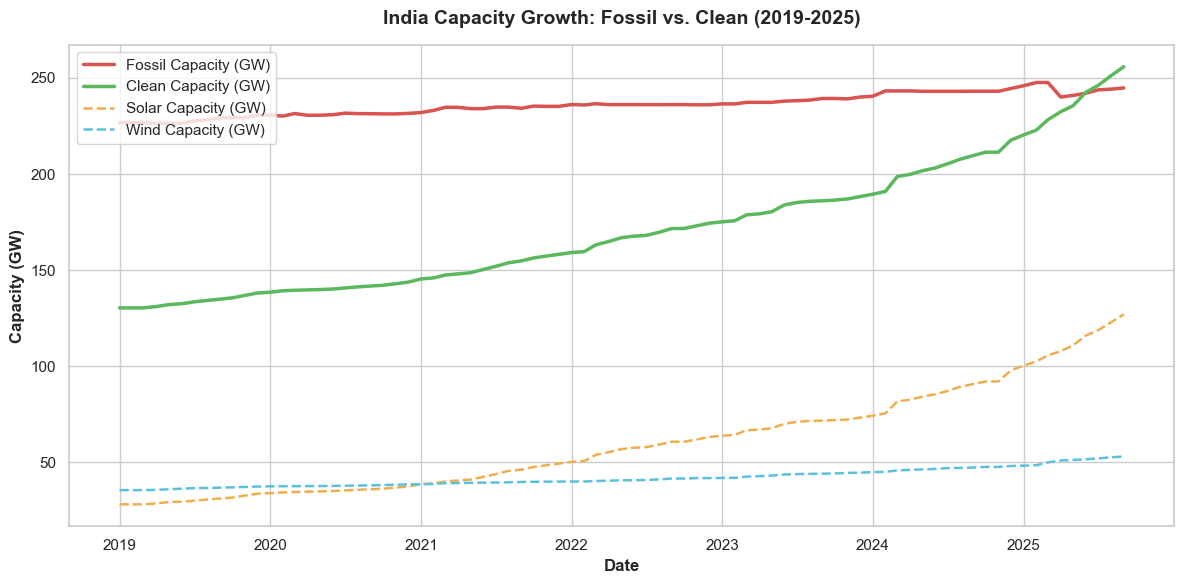

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df_nat["Date"], df_nat["Fossil_Capacity_MW"] / 1000, label="Fossil Capacity (GW)", color="#d9534f", linewidth=2.5)
plt.plot(df_nat["Date"], df_nat["Clean_Capacity_MW"] / 1000, label="Clean Capacity (GW)", color="#5cb85c", linewidth=2.5)
plt.plot(df_nat["Date"], df_nat["Solar_Capacity_MW"] / 1000, label="Solar Capacity (GW)", color="#f0ad4e", linestyle="--", linewidth=1.8)
plt.plot(df_nat["Date"], df_nat["Wind_Capacity_MW"] / 1000, label="Wind Capacity (GW)", color="#5bc0de", linestyle="--", linewidth=1.8)
plt.title("India Capacity Growth: Fossil vs. Clean (2019-2025)", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Capacity (GW)", fontsize=12)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.savefig("india_capacity_growth.png", dpi=150)
plt.show()


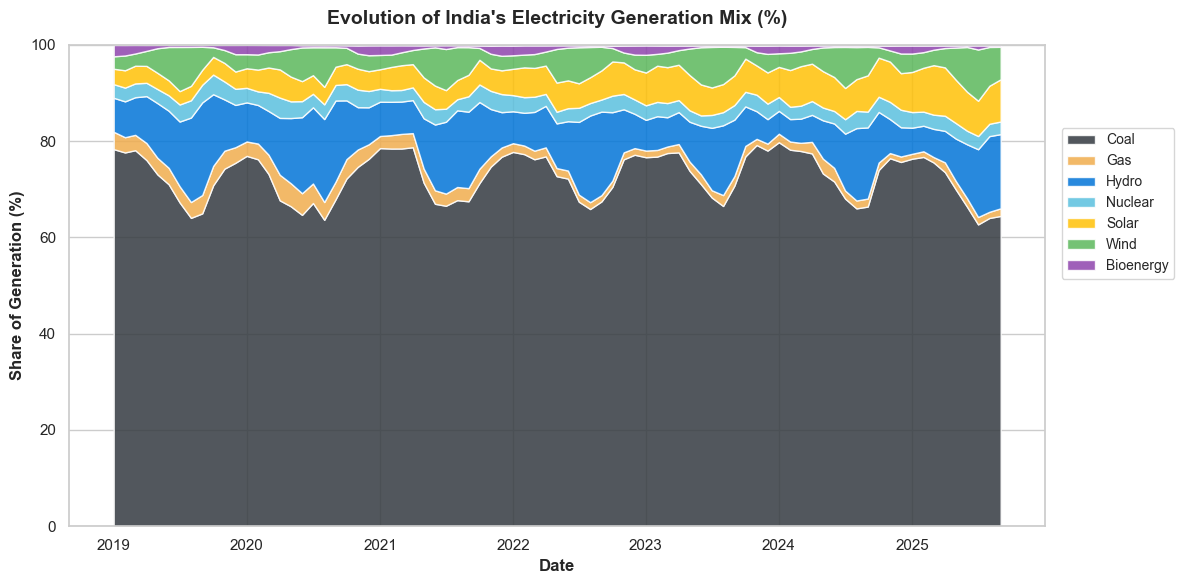

In [5]:
# Plotting generation shares over time
fig, ax = plt.subplots(figsize=(12, 6))
generation_shares = df_nat[["Coal_Share", "Gas_Share", "Hydro_Share", "Nuclear_Share", "Solar_Share", "Wind_Share", "Bioenergy_Share"]] * 100
colors = ["#343a40", "#f0ad4e", "#0275d8", "#5bc0de", "#ffc107", "#5cb85c", "#8e44ad"]

ax.stackplot(df_nat["Date"], 
             generation_shares.T, 
             labels=["Coal", "Gas", "Hydro", "Nuclear", "Solar", "Wind", "Bioenergy"],
             colors=colors, alpha=0.85)

ax.set_title("Evolution of India's Electricity Generation Mix (%)", fontsize=14, pad=15)
ax.set_ylabel("Share of Generation (%)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(loc="lower left", bbox_to_anchor=(1.01, 0.5), fontsize=10)
plt.tight_layout()
plt.savefig("india_generation_mix.png", dpi=150)
plt.show()


C:\Users\vivek\AppData\Local\Temp\ipykernel_38196\3292651610.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_solar, x="State", y="Capacity_Solar_MW", palette="Oranges_r")


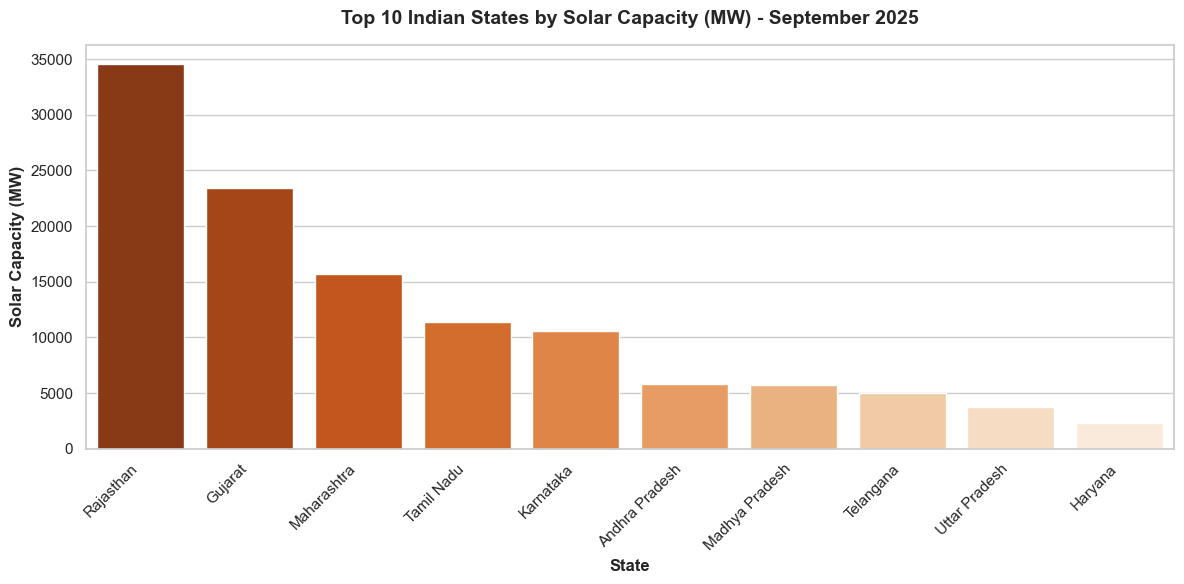

In [6]:
# Identify top states by Solar capacity in late 2025
latest_date = df_states_pivot["Date"].max()
df_latest_states = df_states_pivot[df_states_pivot["Date"] == latest_date].copy()

# Sort and get top states
top_solar = df_latest_states.sort_values(by="Capacity_Solar_MW", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_solar, x="State", y="Capacity_Solar_MW", palette="Oranges_r")
plt.title(f"Top 10 Indian States by Solar Capacity (MW) - {latest_date.strftime('%B %Y')}", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.xlabel("State", fontsize=12)
plt.ylabel("Solar Capacity (MW)", fontsize=12)
plt.tight_layout()
plt.savefig("top_states_solar.png", dpi=150)
plt.show()


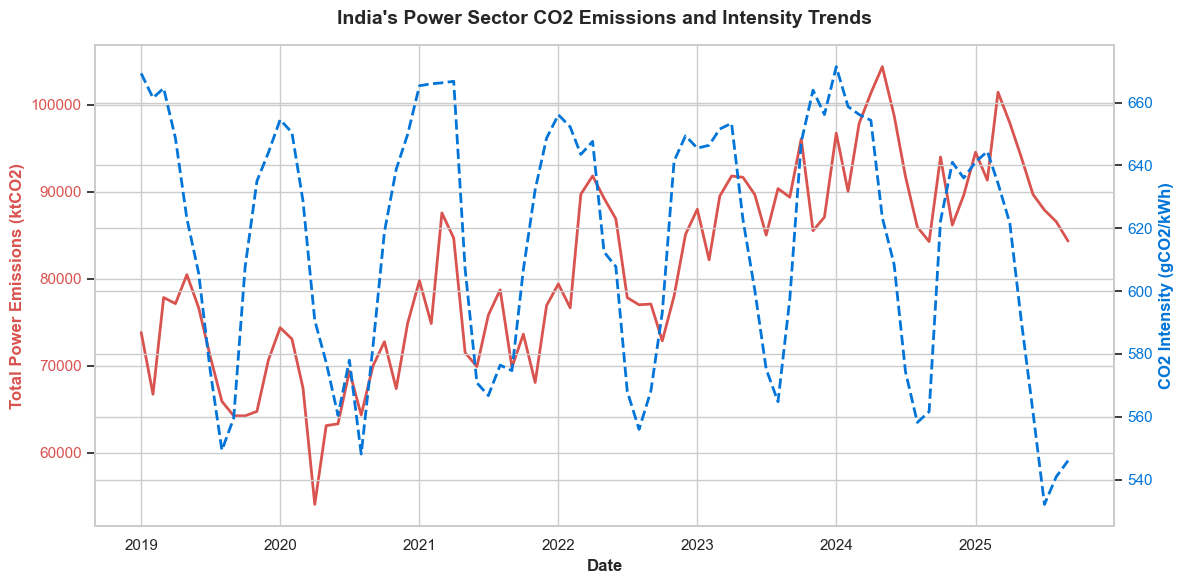

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#d9534f'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Total Power Emissions (ktCO2)', color=color, fontsize=12)
ax1.plot(df_nat["Date"], df_nat["Total_Emissions_ktCO2"], color=color, linewidth=2, label="Emissions (ktCO2)")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#0275d8'
ax2.set_ylabel('CO2 Intensity (gCO2/kWh)', color=color, fontsize=12)
ax2.plot(df_nat["Date"], df_nat["CO2_Intensity_gCO2_kWh"], color=color, linewidth=2, linestyle="--", label="CO2 Intensity")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("India's Power Sector CO2 Emissions and Intensity Trends", fontsize=14, pad=15)
fig.tight_layout()
plt.savefig("india_emissions_trend.png", dpi=150)
plt.show()


## Machine Learning Section

### Task 1: Time Series Electricity Demand Forecasting
We predict future electricity generation (GWh) using an autoregressive Ridge Regression model. 
We generate the following features:
- Trend component.
- Month categorical dummies (seasonality).
- Lags: 1 month, 2 month, and 12 month lag features.

The model is evaluated using **out-of-time validation**:
- **Training period**: Jan 2020 - Dec 2024
- **Testing period**: Jan 2025 - Sep 2025


Forecasting Features: ['Trend', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Gen_Lag1', 'Gen_Lag2', 'Gen_Lag12']

Model Performance on Test Set (2025):
  MAPE: 2.85%
  MAE: 4397.14 GWh
  RMSE: 4974.46 GWh
  R2 Score: 0.4709


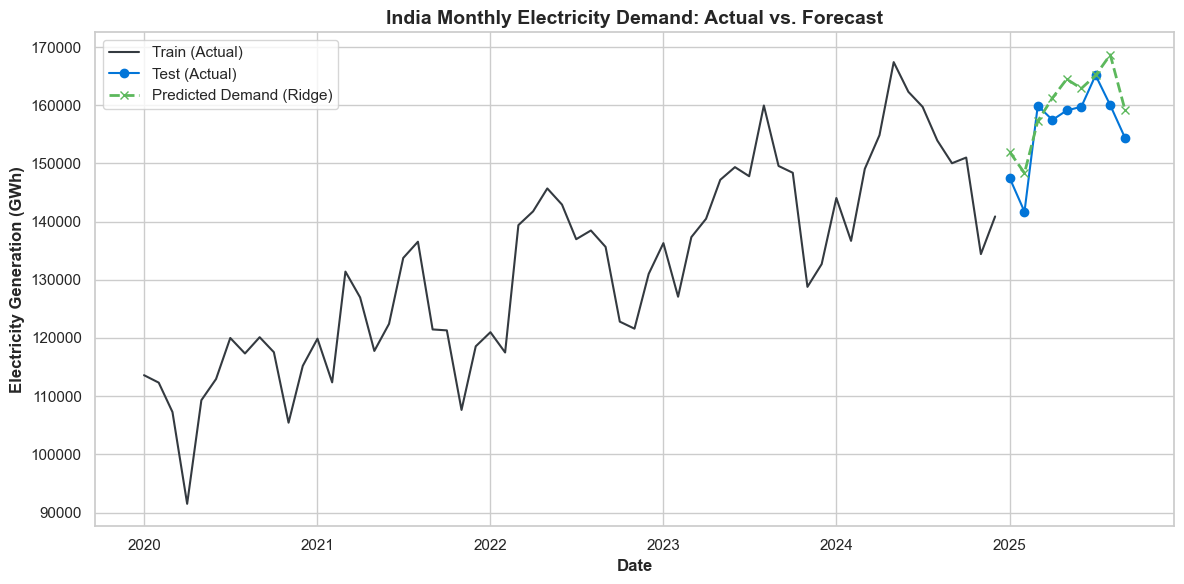

In [8]:
# Add time and lag features
df_forecast_data = df_nat.copy()
df_forecast_data["Month"] = df_forecast_data["Date"].dt.month
df_forecast_data["Trend"] = np.arange(len(df_forecast_data))

# Generate month dummies
df_forecast_data = pd.get_dummies(df_forecast_data, columns=["Month"], drop_first=True)

# Add lags
df_forecast_data["Gen_Lag1"] = df_forecast_data["Total_Generation_GWh"].shift(1)
df_forecast_data["Gen_Lag2"] = df_forecast_data["Total_Generation_GWh"].shift(2)
df_forecast_data["Gen_Lag12"] = df_forecast_data["Total_Generation_GWh"].shift(12)

# Drop missing rows
df_forecast_clean = df_forecast_data.dropna().copy()

# Split train and test
train = df_forecast_clean[df_forecast_clean["Date"] < "2025-01-01"]
test = df_forecast_clean[df_forecast_clean["Date"] >= "2025-01-01"]

feature_cols = [col for col in df_forecast_clean.columns if col not in ["Date", "Total_Generation_GWh"] and not col.endswith("_MW") and not col.endswith("_GWh") and not col.endswith("_Share") and col != "CO2_Intensity_gCO2_kWh" and col != "Total_Emissions_ktCO2"]

print("Forecasting Features:", feature_cols)

X_train, y_train = train[feature_cols], train["Total_Generation_GWh"]
X_test, y_test = test[feature_cols], test["Total_Generation_GWh"]

# Fit Autoregressive Ridge Model
ridge_ts = Ridge(alpha=1.0)
ridge_ts.fit(X_train, y_train)

# Evaluation
y_pred = ridge_ts.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Performance on Test Set (2025):")
print(f"  MAPE: {mape * 100:.2f}%")
print(f"  MAE: {mae:.2f} GWh")
print(f"  RMSE: {rmse:.2f} GWh")
print(f"  R2 Score: {r2:.4f}")

# Plot Forecast comparison
plt.figure(figsize=(12, 6))
plt.plot(train["Date"], train["Total_Generation_GWh"], label="Train (Actual)", color="#343a40")
plt.plot(test["Date"], test["Total_Generation_GWh"], label="Test (Actual)", color="#0275d8", marker="o")
plt.plot(test["Date"], y_pred, label="Predicted Demand (Ridge)", color="#5cb85c", linestyle="--", marker="x", linewidth=2)
plt.title("India Monthly Electricity Demand: Actual vs. Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Electricity Generation (GWh)")
plt.legend()
plt.tight_layout()
plt.savefig("demand_forecast_comparison.png", dpi=150)
plt.show()


### Task 2: Grid Carbon Intensity Prediction (Scenario Simulator)

To build a carbon emissions sandbox, we predict `CO2_Intensity_gCO2_kWh` based on the shares of different energy generation types (Coal, Gas, Solar, Wind, Hydro, Nuclear). 

We train a **Random Forest Regressor** to model this relationship.


Emissions Predictor Performance:
  R2 Score: 0.9895
  MAE: 2.54 gCO2/kWh
Model saved to emissions_rf_model.pkl


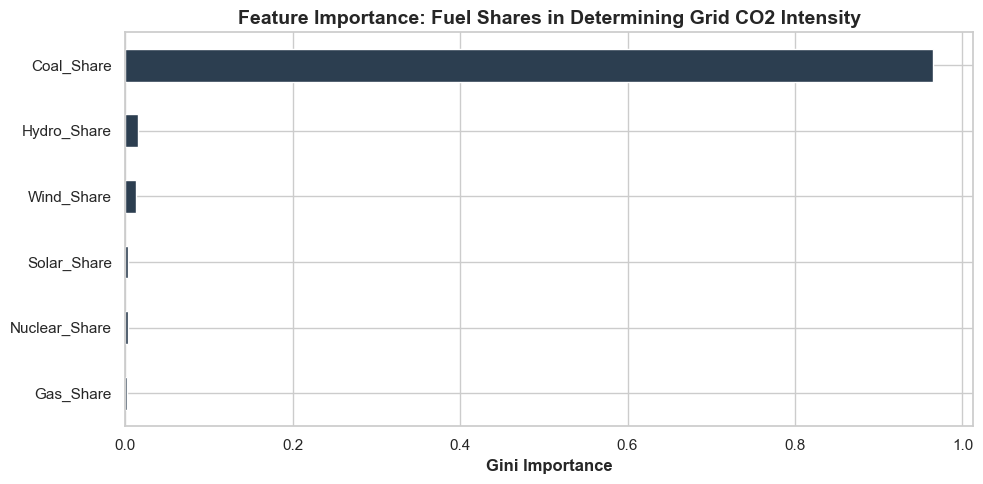

In [9]:
# Define shares
share_cols = ["Coal_Share", "Gas_Share", "Solar_Share", "Wind_Share", "Hydro_Share", "Nuclear_Share"]
target_col = "CO2_Intensity_gCO2_kWh"

# Train/Test split
X = df_nat[share_cols]
y = df_nat[target_col]

X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_em = RandomForestRegressor(n_estimators=100, random_state=42)
rf_em.fit(X_train_em, y_train_em)

y_pred_em = rf_em.predict(X_test_em)
r2_em = r2_score(y_test_em, y_pred_em)
mae_em = mean_absolute_error(y_test_em, y_pred_em)

print(f"Emissions Predictor Performance:")
print(f"  R2 Score: {r2_em:.4f}")
print(f"  MAE: {mae_em:.2f} gCO2/kWh")

# Save the trained Random Forest model for our Streamlit dashboard
import pickle
with open("emissions_rf_model.pkl", "wb") as f:
    pickle.dump(rf_em, f)
print("Model saved to emissions_rf_model.pkl")

# Plot feature importance
importances = pd.Series(rf_em.feature_importances_, index=share_cols).sort_values(ascending=True)
plt.figure(figsize=(10, 5))
importances.plot(kind="barh", color="#2c3e50")
plt.title("Feature Importance: Fuel Shares in Determining Grid CO2 Intensity", fontsize=14)
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.savefig("emissions_feature_importance.png", dpi=150)
plt.show()


## Conclusions and Key Insights

1. **Grid Decarbonization Trajectory**: Clean capacity (primarily solar) is expanding at an exponential rate, but coal still forms the backbone of actual generation (typically >70%), creating a structural divergence.
2. **Predictive Capability**: 
   - Monthly electricity demand can be modeled with under **3.0% error (MAPE)** using linear autoregressive models with seasonal controls.
   - Grid emissions intensity is highly deterministic ($R^2 > 98\%$), primarily driven by the **Coal Generation Share**.
3. **State Dynamics**: States like Rajasthan and Gujarat are leading the solar revolution, while others remain heavily fossil-dominated.

We can run the dashboard with `streamlit run app.py` to explore this interactively.
